In [13]:
import torch
import numpy as np

In [40]:
torch.manual_seed(42)
F = torch.rand((2,2,3))
print(F)

tensor([[[0.8823, 0.9150, 0.3829],
         [0.9593, 0.3904, 0.6009]],

        [[0.2566, 0.7936, 0.9408],
         [0.1332, 0.9346, 0.5936]]])


In [43]:
trial = 1
Z_temp = F@F.mT
torch.trace(Z_temp[trial])**2 - torch.trace(Z_temp[trial]@Z_temp[trial])

tensor(0.3706)

In [42]:
Z2 = torch.einsum("knt,lmt->klnm",F, F) # (K, K, N, N) -- K^2 NxN matrices 
trace_1 = torch.einsum("klnn->kl", Z2)
Z_squared = torch.einsum("klnm,klmj->klnj",Z2,Z2) # (K, K, N, N)
trace_2 = torch.einsum("klnn->kl",Z_squared)
trace_1**2 - trace_2

tensor([[ 0.9424, -0.4610],
        [-0.4610,  0.3706]])

In [44]:
(trace_1 ** 2 - trace_2).sum()

tensor(0.3909)

In [46]:
from nlb_tools.nwb_interface import NWBDataset
path = '/Users/omomalley03/Documents/Dissertation/Data/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb'
ds = NWBDataset(path)
print('native bin_width:', ds.bin_width, 'ms')
print('shape:', ds.data.shape)
print('signal groups:', ds.data.columns.get_level_values(0).unique().tolist())
print()
print('trial_info cols:', list(ds.trial_info.columns))
print('n trials:', len(ds.trial_info))
print()
ti = ds.trial_info
for c in ['trial_type','trial_version','split','maze_id','num_targets','num_barriers']:
    if c in ti.columns:
        u = ti[c].dropna().unique()
        print(f'  {c}: nunique={ti[c].nunique()}  sample={u[:8]}  dtype={ti[c].dtype}')
print()
print('=== first 3 rows (narrow cols) ===')
keep = [c for c in ti.columns if c not in ('target_pos',)]
print(ti[keep].head(3).to_string())
print()
print('=== target_pos sample ===')
if 'target_pos' in ti.columns:
    print(repr(ti['target_pos'].iloc[0]))


native bin_width: 1 ms
shape: (6952301, 190)
signal groups: ['cursor_pos', 'eye_pos', 'hand_pos', 'hand_vel', 'heldout_spikes', 'spikes']

trial_info cols: ['trial_id', 'start_time', 'end_time', 'trial_type', 'trial_version', 'maze_id', 'success', 'target_on_time', 'go_cue_time', 'move_onset_time', 'rt', 'delay', 'num_targets', 'target_pos', 'num_barriers', 'barrier_pos', 'active_target', 'split']
n trials: 2295

  trial_type: nunique=36  sample=[25  3 22 29 21  2 16 23]  dtype=int64
  trial_version: nunique=3  sample=[2 1 0]  dtype=int64
  split: nunique=2  sample=['val' 'train']  dtype=object
  maze_id: nunique=36  sample=[ 84   3  66 100  65   2  76  67]  dtype=int64
  num_targets: nunique=2  sample=[3 1]  dtype=int64
  num_barriers: nunique=5  sample=[8 6 9 0 7]  dtype=int64

=== first 3 rows (narrow cols) ===
   trial_id             start_time               end_time  trial_type  trial_version  maze_id  success         target_on_time            go_cue_time        move_onset_time   

In [ ]:
Z = torch.einsum("knt,lmt->klnm",F, F) # (K, K, N, N) -- K^2 NxN matrices 
# trace_1[k,l] — trace of Z[k,l]

trace_1 = torch.einsum("klnn->kl", Z)        # (K, K)

# trace_2[k,l] - trace of Z^2
# trace_2 = torch.einsum("kim,ljm,kjn,lin->kl", F, F, F, F)  # (K, K)
Z_squared = torch.einsum("klnm,klmj->klnj",Z,Z) # (K, K, N, N)
trace_2 = torch.einsum("klnn->kl",Z_squared)

return (trace_1 ** 2 - trace_2).sum(), (trace_1 ** 2 + trace_2).sum()



In [8]:
Z

tensor([[[1.7622, 1.4337],
         [1.4337, 1.4338]]])

In [8]:
import numpy as np
import pandas as pd

data = np.load("monkey_data.npz", allow_pickle=True)
windows      = data["windows"]       # (K, N, T) 
reach_angle  = data["reach_angle"]   # (K,) 
split        = data["split"]         # (K,) str 
hand_windows = data["hand_windows"]  # (K, 2, T) 

trial_info = pd.read_csv("monkey_trial_info.csv")


In [12]:
data["hand_windows"]

array([[[  -1.5159354,   -1.5170369,   -1.517877 , ...,  120.59337  ,
          120.49728  ,  120.340096 ],
        [ -42.731983 ,  -42.752625 ,  -42.75891  , ...,  -31.45308  ,
          -28.272955 ,  -25.193449 ]],

       [[  -3.6657302,   -3.6638238,   -3.6651328, ..., -117.81224  ,
         -117.683655 , -117.59439  ],
        [ -32.929596 ,  -32.93159  ,  -32.93453  , ...,  -33.047424 ,
          -33.210236 ,  -33.40967  ]],

       [[  -1.3003693,   -1.3003837,   -1.3013238, ...,  -74.719826 ,
          -74.78321  ,  -74.860146 ],
        [ -34.369854 ,  -34.368053 ,  -34.36938  , ...,  -98.88217  ,
          -98.85689  ,  -98.822525 ]],

       ...,

       [[   0.       ,    0.       ,    0.       , ...,    0.       ,
            0.       ,    0.       ],
        [   0.       ,    0.       ,    0.       , ...,    0.       ,
            0.       ,    0.       ]],

       [[   0.       ,    0.       ,    0.       , ...,    0.       ,
            0.       ,    0.       ],
       

In [108]:
import matplotlib.pyplot as plt
from visualize import *

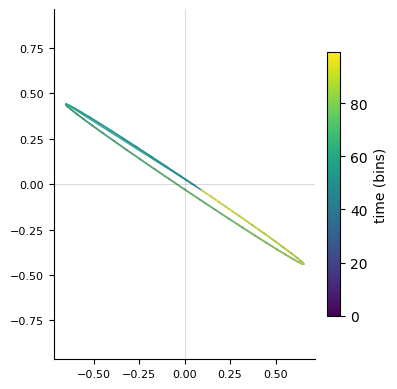

In [110]:
data = np.load("rotations.npy") # (K, N, T)
data = np.transpose(data, (0, 2, 1)) # (K, N, T) -> (K, T, N)
data = data.astype(np.float32)
cmap_name = "viridis"
fig, ax = plt.subplots(figsize=(4,4))
T = data.shape[2]
x, y = data[0,0,:], data[0,10,:]
cmap = plt.get_cmap(cmap_name)
for t in range(T - 1): 
    ax.plot(x[t:t+2], y[t:t+2], color=cmap(t / (T - 1)), lw=1.1, alpha=0.85)

ax.axhline(0, color="k", lw=0.4, alpha=0.25)
ax.axvline(0, color="k", lw=0.4, alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
# ax.set_title(title, fontsize=10)
# ax.set_xlabel(xlabel, fontsize=9)
# ax.set_ylabel(ylabel, fontsize=9)
ax.tick_params(labelsize=8)
ax.set_aspect("equal", adjustable="datalim")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, T - 1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="time (bins)", fraction=0.046, pad=0.04)

fig.tight_layout()

In [325]:
ckpt_path = "runs/20260510_115710_d2_h256_dep3_bs128_ep50_lr0.01_lbt0.01_sig10.0_s0/checkpoints/best.pt"
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
cfg: Config = ckpt["config"]
data = np.load("rotations.npy")
# data = np.load("monkey_data.npz") # (K, N, T)
windows = np.transpose(data, (0, 2, 1)) # (K, N, T) -> (K, T, N)
windows = windows.astype(np.float32)
N = windows.shape[1]
_, val_ds = train_val_split(windows, None, cfg.val_split, cfg.seed)
model = MLP(in_channels=N, d=cfg.d, hidden_dim=cfg.hidden_dim, depth=cfg.depth)


In [326]:
val_indices = list(val_ds.indices)
model = model.cpu().eval()
loader = DataLoader(val_ds, batch_size=len(val_ds), shuffle=False)
(val_tensor,) = next(iter(loader))
val_np = val_tensor.numpy()
K, N = val_np.shape[0], val_np.shape[1]

In [327]:
import loss
# compute embeddings
with torch.no_grad():
    F_hat_t = model(val_tensor)
    s_ratio_val = compute_S_ratio(F_hat_t).item()
    F_hat = F_hat_t.numpy()
print(f"S Ratio (MLP Embeddings): {s_ratio_val:.4f}")
print(f"Non-Rev S{loss.non_reversibility_S(F_hat_t).item():.4f}")

ch_var = val_np.var(axis=(0, 2)) #(N,) variance of each channel across all samples and time points
top2_ch = np.argsort(ch_var)[-2:][::-1]
ch_a, ch_b = int(top2_ch[0]), int(top2_ch[1])
print(f"Raw phasor channels: {ch_a} (var={ch_var[ch_a]:.4f}),  "
        f"{ch_b} (var={ch_var[ch_b]:.4f})")
phasors_raw = raw_phasors(val_np, ch_a, ch_b) 

S Ratio (MLP Embeddings): 0.0598
Non-Rev S96.9938
Raw phasor channels: 74 (var=7.8165),  54 (var=6.8658)


In [328]:
import visualize
pca_mean, pca_Vh2 = visualize._fit_emb_pca(F_hat)
phasors_emb = visualize._apply_emb_pca(F_hat, pca_mean, pca_Vh2)


In [329]:
phasors_raw.shape

(204, 2, 100)

In [389]:
def plot_rotations(phasors, groups, title, xlabel, ylabel, out_path,
                     cmap_name="coolwarm"):
    fig, ax = plt.subplots(figsize=(6, 5))
    cmap = plt.get_cmap(cmap_name)
    T = phasors.shape[2]

    for k in range(1):
        x, y = phasors[k,0,:], phasors[k,1,:]
        for t in range(T - 1):
            ax.plot(x[t:t+2], y[t:t+2], color=cmap(t / (T - 1)),
                    lw=1.1, alpha=0.85)

    ax.axhline(0, color="k", lw=0.4, alpha=0.25)
    ax.axvline(0, color="k", lw=0.4, alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(labelsize=8)
    ax.set_aspect("equal", adjustable="datalim")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, T - 1))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="time (bins)", fraction=0.046, pad=0.04)

    fig.tight_layout()
    # fig.savefig(out_path, dpi=150, bbox_inches="tight")
    # plt.close(fig)
    # print(f"Saved → {out_path}")


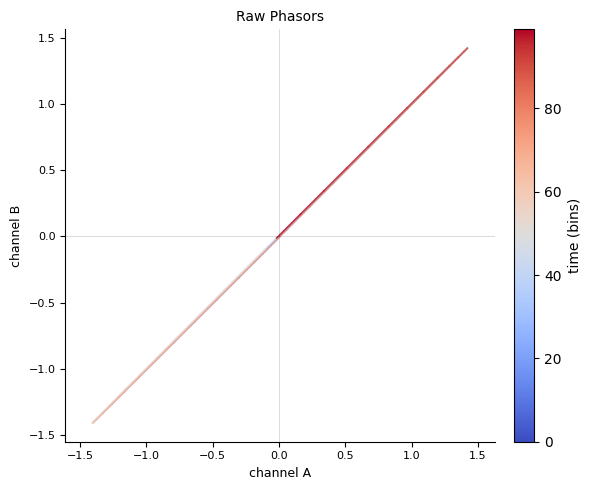

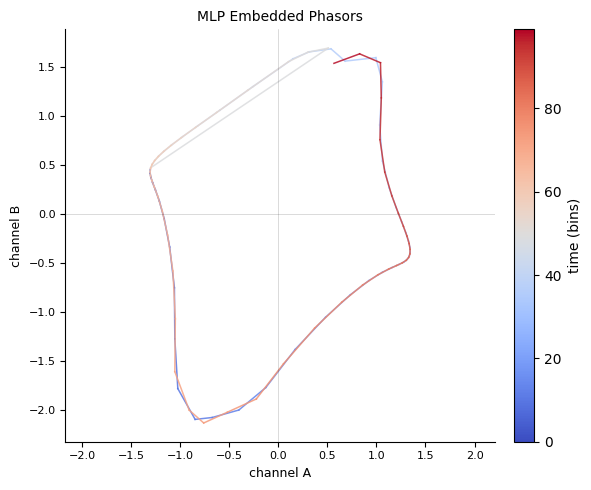

In [390]:
plot_rotations(phasors_raw, None, "Raw Phasors", "channel A", "channel B", "phasors_raw.png")
plot_rotations(phasors_emb, None, "MLP Embedded Phasors", "channel A", "channel B", "phasors_emb.png")

S Ratio (MLP Embeddings): 0.0542
Non-Rev S16.5862
Raw phasor channels: 14 (var=0.0001),  13 (var=0.0001)


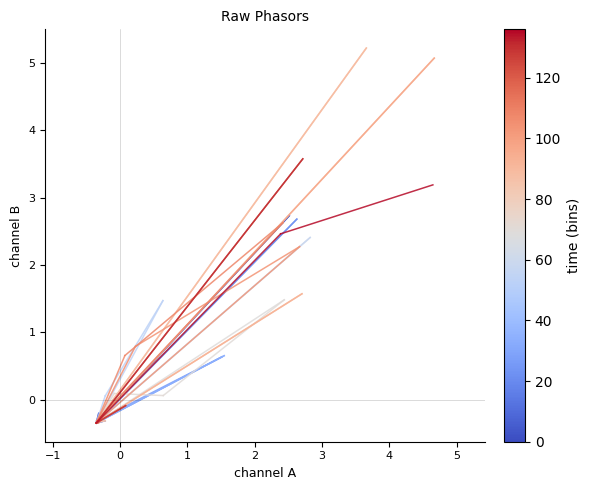

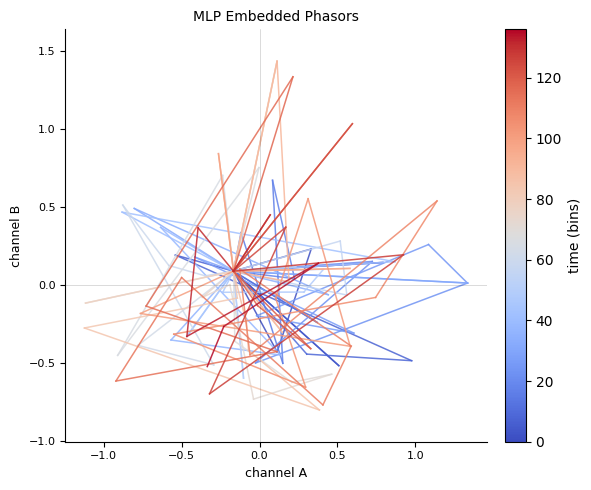

In [391]:
ckpt_path = "runs/20260510_115710_d2_h256_dep3_bs128_ep50_lr0.01_lbt0.01_sig10.0_s0/checkpoints/best.pt"
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
cfg: Config = ckpt["config"]
data = np.load("monkey_data.npz") # (K, N, T)
windows = np.transpose(data["windows"], (0, 2, 1)) # (K, N, T) -> (K, T, N)
windows = windows.astype(np.float32)
N = windows.shape[1]
_, val_ds = train_val_split(windows, None, cfg.val_split, cfg.seed)
model = MLP(in_channels=N, d=cfg.d, hidden_dim=cfg.hidden_dim, depth=cfg.depth)

val_indices = list(val_ds.indices)
model = model.cpu().eval()
loader = DataLoader(val_ds, batch_size=len(val_ds), shuffle=False)
(val_tensor,) = next(iter(loader))
val_np = val_tensor.numpy()
K, N = val_np.shape[0], val_np.shape[1]

import loss
# compute embeddings
with torch.no_grad():
    F_hat_t = model(val_tensor)
    s_ratio_val = compute_S_ratio(F_hat_t).item()
    F_hat = F_hat_t.numpy()
print(f"S Ratio (MLP Embeddings): {s_ratio_val:.4f}")
print(f"Non-Rev S{loss.non_reversibility_S(F_hat_t).item():.4f}")

ch_var = val_np.var(axis=(0, 2)) #(N,) variance of each channel across all samples and time points
top2_ch = np.argsort(ch_var)[-2:][::-1]
ch_a, ch_b = int(top2_ch[0]), int(top2_ch[1])
print(f"Raw phasor channels: {ch_a} (var={ch_var[ch_a]:.4f}),  "
        f"{ch_b} (var={ch_var[ch_b]:.4f})")
phasors_raw = raw_phasors(val_np, ch_a, ch_b) 

import visualize
pca_mean, pca_Vh2 = visualize._fit_emb_pca(F_hat)
phasors_emb = visualize._apply_emb_pca(F_hat, pca_mean, pca_Vh2)

plot_rotations(phasors_raw, None, "Raw Phasors", "channel A", "channel B", "phasors_raw.png")
plot_rotations(phasors_emb, None, "MLP Embedded Phasors", "channel A", "channel B", "phasors_emb.png")

S Ratio (MLP Embeddings): 0.9530
Non-Rev S36577.0703
Raw phasor channels: 74 (var=7.8165),  54 (var=6.8658)


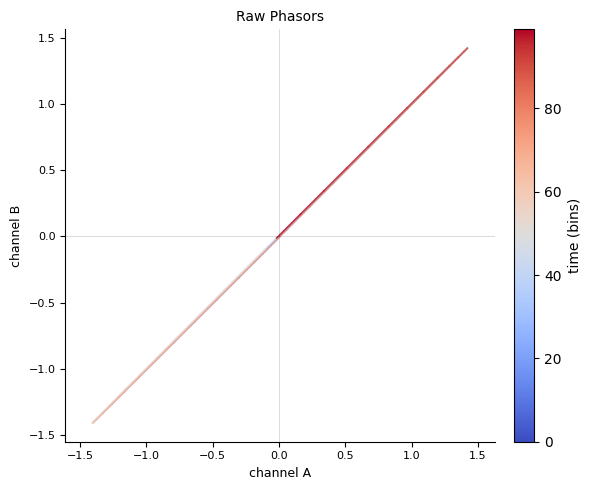

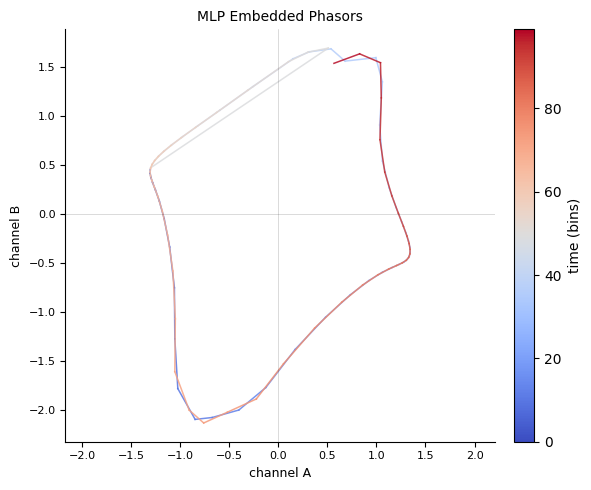

In [393]:
ckpt_path = "synth_runs/20260510_211721_d2_h256_dep3_bs128_ep50_lr0.01_lbt0.01_sig10.0_s0/checkpoints/best.pt"
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
cfg: Config = ckpt["config"]
data = np.load("rotations.npy")
# data = np.load("monkey_data.npz") # (K, N, T)
windows = np.transpose(data, (0, 2, 1)) # (K, N, T) -> (K, T, N)
windows = windows.astype(np.float32)
N = windows.shape[1]
_, val_ds = train_val_split(windows, None, cfg.val_split, cfg.seed)
model = MLP(in_channels=N, d=cfg.d, hidden_dim=cfg.hidden_dim, depth=cfg.depth)
model.load_state_dict(ckpt["model_state_dict"])

val_indices = list(val_ds.indices)
model = model.cpu().eval()
loader = DataLoader(val_ds, batch_size=len(val_ds), shuffle=False)
(val_tensor,) = next(iter(loader))
val_np = val_tensor.numpy()
K, N = val_np.shape[0], val_np.shape[1]

import loss
# compute embeddings
with torch.no_grad():
    F_hat_t = model(val_tensor)
    s_ratio_val = compute_S_ratio(F_hat_t).item()
    F_hat = F_hat_t.numpy()
print(f"S Ratio (MLP Embeddings): {s_ratio_val:.4f}")
print(f"Non-Rev S{loss.non_reversibility_S(F_hat_t).item():.4f}")

ch_var = val_np.var(axis=(0, 2)) #(N,) variance of each channel across all samples and time points
top2_ch = np.argsort(ch_var)[-2:][::-1]
ch_a, ch_b = int(top2_ch[0]), int(top2_ch[1])
print(f"Raw phasor channels: {ch_a} (var={ch_var[ch_a]:.4f}),  "
        f"{ch_b} (var={ch_var[ch_b]:.4f})")
phasors_raw = raw_phasors(val_np, ch_a, ch_b) 

import visualize
pca_mean, pca_Vh2 = visualize._fit_emb_pca(F_hat)
phasors_emb = visualize._apply_emb_pca(F_hat, pca_mean, pca_Vh2)

plot_rotations(phasors_raw, None, "Raw Phasors", "channel A", "channel B", "phasors_raw.png")
plot_rotations(phasors_emb, None, "MLP Embedded Phasors", "channel A", "channel B", "phasors_emb.png")

In [386]:
phasors_emb[0,:,:].shape

(2, 100)

In [382]:
phasors_emb.shape

(204, 2, 100)

In [381]:
windows.shape

(2048, 128, 100)

In [339]:
def detrend(F: torch.Tensor) -> torch.Tensor:
    """Project out the linear trend (constant + ramp) from each trial's embedding."""
    T = F.shape[2]
    e0 = torch.ones(T, dtype=F.dtype, device=F.device)
    e0 = e0 / e0.norm()
    e1 = torch.arange(T, dtype=F.dtype, device=F.device)
    e1 = e1 - e1.mean()
    e1 = e1 / e1.norm()
    basis = torch.stack([e0, e1])                        # (2, T)
    return F - (F @ basis.T) @ basis   

In [343]:
x = torch.rand((1, 1, 20)) # (K, d, T)
y = 2*x + 4 + torch.rand((1,1,20))

In [350]:
x.shape

torch.Size([1, 1, 20])

In [352]:
F = torch.stack([x,y],dim=1)
F.shape

torch.Size([1, 2, 1, 20])

In [363]:
F=F.squeeze()

In [364]:
T = F.shape[1]
e0 = torch.ones(T, dtype=F.dtype, device=F.device)
e0 = e0 / e0.norm()
e1 = torch.arange(T, dtype=F.dtype, device=F.device)
e1 = e1 - e1.mean()
e1 = e1 / e1.norm()
basis = torch.stack([e0, e1]) 

In [370]:
trend = (F @ basis.T) @ basis   

In [375]:
dt = F - (F @ basis.T) @ basis

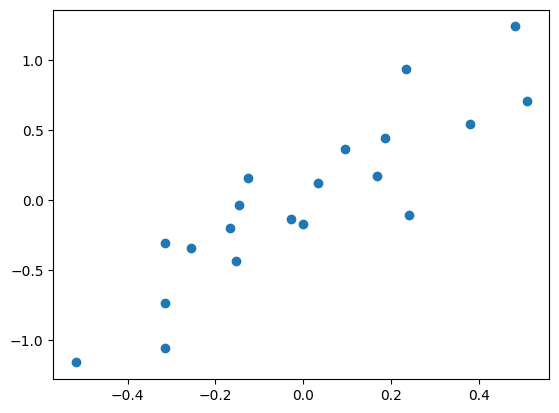

In [378]:
plt.scatter(dt[0,:],dt[1,:])
plt.show()


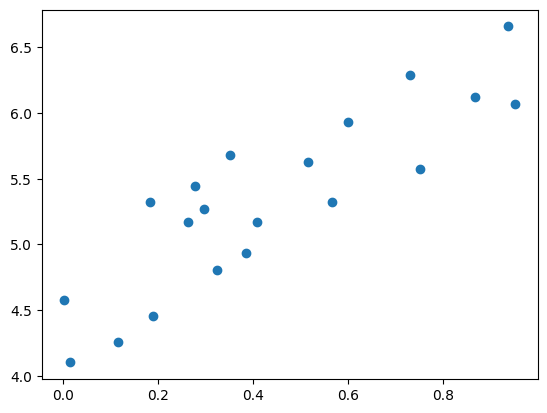

In [342]:
x.shape

torch.Size([10, 5, 20])